# Notebook 1 / 3 — Data Creation
Loads MS COCO 2017 backgrounds, adds synthetic shapes, auto-generates
bounding-box labels, saves images into `train/ val/ test/` with one `*_labels.json` each, and zips it.
Run once with `SMALL_TEST=True` to verify, then `SMALL_TEST=False` for the real protocol.


In [ ]:
# Cell 1 — Setup
!pip install -q pycocotools opencv-python-headless

In [ ]:
# Cell 2 — Config
import os, json, time, hashlib, shutil
import numpy as np
from torchvision.datasets import CocoDetection
GLOBAL_SEED = 2025; np.random.seed(GLOBAL_SEED)
POS_RATIO = 0.7; USE_DISTRACTORS = True; MAX_SIDE = 512
SMALL_TEST = False
if SMALL_TEST: N_TRAIN, N_VAL, N_TEST = 300, 200, 200
else:          N_TRAIN, N_VAL, N_TEST = 5000, 1000, 1000   # required fixed protocol
OUT = "synthetic_data"; os.makedirs(OUT, exist_ok=True)
print("SMALL_TEST =", SMALL_TEST, "| sizes:", N_TRAIN, N_VAL, N_TEST)

SMALL_TEST = False | sizes: 5000 1000 1000


In [ ]:
# Cell 3 — Download COCO 2017
import subprocess
def sh(c): print(">", c); subprocess.run(c, shell=True, check=False)
sh("mkdir -p data/coco")
sh("wget -c -q http://images.cocodataset.org/zips/val2017.zip -P data/coco/")
sh("wget -c -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip -P data/coco/")
sh("unzip -q -o data/coco/val2017.zip -d data/coco/")
sh("unzip -q -o data/coco/annotations_trainval2017.zip -d data/coco/")
if not SMALL_TEST:
    sh("wget -c http://images.cocodataset.org/zips/train2017.zip -P data/coco/")
    sh("unzip -q -o data/coco/train2017.zip -d data/coco/")
print("Download done.")

> mkdir -p data/coco
> wget -c -q http://images.cocodataset.org/zips/val2017.zip -P data/coco/
> wget -c -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip -P data/coco/
> unzip -q -o data/coco/val2017.zip -d data/coco/
> unzip -q -o data/coco/annotations_trainval2017.zip -d data/coco/
> wget -c http://images.cocodataset.org/zips/train2017.zip -P data/coco/
> unzip -q -o data/coco/train2017.zip -d data/coco/
Download done.


In [ ]:
# Cell 4 — # Synthetic shape generator. All randomness comes from one reproducible seed.
# Difficulty mechanisms (>=4 required): random opacity, partial transparency, anti-aliasing,
# random blur, additive noise, low-contrast/image-statistic colors, overlapping shapes,
# rotation, line segments, stars, distractor shapes (unlabeled) and hard-negative images.
import numpy as np, hashlib
from PIL import Image, ImageDraw, ImageFilter

TARGET_SHAPES = ["circle", "rectangle", "triangle", "ellipse", "polygon", "line", "star"]

def make_seed(split_name, image_id, global_seed=2025):
    key = f"{split_name}_{image_id}_{global_seed}".encode("utf-8")
    return int(hashlib.sha256(key).hexdigest()[:8], 16)

def _star_points(cx, cy, r, rot):
    pts = []
    for k in range(10):
        rr = r if k % 2 == 0 else r * 0.45
        a = rot + k * np.pi / 5
        pts.append((cx + rr*np.cos(a), cy + rr*np.sin(a)))
    return pts

def _local_color(arr, cx, cy, size, rng):
    H, W = arr.shape[:2]
    patch = arr[max(0,cy-size):min(H,cy+size), max(0,cx-size):min(W,cx+size)]
    mean = patch.reshape(-1,3).mean(0) if patch.size else np.array([128.,128.,128.])
    return tuple(int(np.clip(c,0,255)) for c in mean + rng.normal(0, 35, 3))

def _draw_target(W, H, rng, arr, ss=4, opacity_range=(70, 200)):
    s = min(W, H)
    size = int(rng.integers(int(0.08*s), max(int(0.08*s)+1, int(0.28*s))))
    cx = int(rng.integers(size, max(size+1, W - size)))
    cy = int(rng.integers(size, max(size+1, H - size)))
    color = _local_color(arr, cx, cy, size, rng)          # low-contrast image-statistic color
    opacity = int(rng.integers(opacity_range[0], opacity_range[1]))   # random opacity
    fill = color + (opacity,)
    layer = Image.new("RGBA", (W*ss, H*ss), (0,0,0,0))
    d = ImageDraw.Draw(layer)
    CX, CY, SZ = cx*ss, cy*ss, size*ss
    t = str(rng.choice(TARGET_SHAPES))
    if t == "circle":      d.ellipse([CX-SZ, CY-SZ, CX+SZ, CY+SZ], fill=fill)
    elif t == "ellipse":   d.ellipse([CX-SZ, CY-SZ//2, CX+SZ, CY+SZ//2], fill=fill)
    elif t == "rectangle": d.rectangle([CX-SZ, CY-SZ//2, CX+SZ, CY+SZ//2], fill=fill)
    elif t == "triangle":  d.polygon([(CX,CY-SZ),(CX-SZ,CY+SZ),(CX+SZ,CY+SZ)], fill=fill)
    elif t == "star":      d.polygon(_star_points(CX, CY, SZ, rng.uniform(0, 2*np.pi)), fill=fill)
    elif t == "line":
        a = rng.uniform(0, 2*np.pi)
        d.line([(CX-SZ*np.cos(a), CY-SZ*np.sin(a)), (CX+SZ*np.cos(a), CY+SZ*np.sin(a))],
               fill=fill, width=max(2, int(SZ*0.22)))      # thick line segment
    else:
        k = int(rng.integers(5, 8)); ang = np.sort(rng.uniform(0, 2*np.pi, k))
        d.polygon([(CX+SZ*np.cos(a), CY+SZ*np.sin(a)) for a in ang], fill=fill)
    layer = layer.rotate(float(rng.uniform(0, 360)), resample=Image.BILINEAR, center=(CX, CY))  # rotation
    layer = layer.resize((W, H), Image.LANCZOS)            # supersample down -> anti-aliasing
    alpha = np.asarray(layer.split()[-1])
    ys, xs = np.where(alpha > 10)
    if len(xs) == 0:
        return None, None
    return layer, [int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())]

def _draw_distractor(W, H, rng, ss=4):
    # Thin OUTLINE shape: visually distinct from filled targets, NOT added to labels.
    s = min(W, H)
    size = int(rng.integers(int(0.06*s), max(int(0.06*s)+1, int(0.20*s))))
    cx = int(rng.integers(size, max(size+1, W - size)))
    cy = int(rng.integers(size, max(size+1, H - size)))
    col = tuple(int(c) for c in rng.integers(0, 256, 3)) + (int(rng.integers(120, 220)),)
    layer = Image.new("RGBA", (W*ss, H*ss), (0,0,0,0))
    d = ImageDraw.Draw(layer)
    CX, CY, SZ = cx*ss, cy*ss, size*ss
    wdt = max(2, int(SZ*0.06))
    if rng.random() < 0.5:
        d.ellipse([CX-SZ, CY-SZ, CX+SZ, CY+SZ], outline=col, width=wdt)
    else:
        d.rectangle([CX-SZ, CY-SZ, CX+SZ, CY+SZ], outline=col, width=wdt)
    layer = layer.rotate(float(rng.uniform(0, 360)), resample=Image.BILINEAR, center=(CX, CY))
    return layer.resize((W, H), Image.LANCZOS)

def generate_sample(pil_img, seed, pos_ratio=0.7, use_distractors=True, max_side=512, opacity_range=(70,200)):
    # Returns (modified_PIL_image, list_of_boxes_xyxy, is_positive)
    rng = np.random.default_rng(seed)
    img = pil_img.convert("RGB")
    w0, h0 = img.size
    scale = max_side / max(w0, h0)
    if scale < 1.0:
        img = img.resize((int(w0*scale), int(h0*scale)), Image.LANCZOS)
    W, H = img.size
    arr = np.asarray(img).astype(np.float32)
    is_positive = bool(rng.random() < pos_ratio)
    boxes = []
    if is_positive:
        for _ in range(int(rng.integers(1, 4))):           # 1..3 target shapes (may overlap)
            layer, bbox = _draw_target(W, H, rng, arr, opacity_range=opacity_range)
            if layer is None:
                continue
            img = Image.alpha_composite(img.convert("RGBA"), layer).convert("RGB")
            boxes.append(bbox)
    if use_distractors and rng.random() < 0.4:             # distractors -> hard negatives
        for _ in range(int(rng.integers(1, 3))):
            img = Image.alpha_composite(img.convert("RGBA"), _draw_distractor(W, H, rng)).convert("RGB")
    if rng.random() < 0.5:                                 # random blur
        img = img.filter(ImageFilter.GaussianBlur(float(rng.uniform(0.3, 1.2))))
    a = np.asarray(img).astype(np.float32) + rng.normal(0, rng.uniform(2, 10), (H, W, 3))  # additive noise
    img = Image.fromarray(np.clip(a, 0, 255).astype(np.uint8))
    boxes = [b for b in boxes if b[2] > b[0] and b[3] > b[1]]
    return img, boxes, is_positive

In [ ]:
# Cell 5 — Fixed train/val/test split
val_base = CocoDetection("data/coco/val2017", "data/coco/annotations/instances_val2017.json")
val_pos  = list(range(0, N_VAL)); test_pos = list(range(N_VAL, N_VAL + N_TEST))
if SMALL_TEST:
    train_base = val_base
    train_pos  = list(range(2000, min(5000, 2000 + N_TRAIN)))   # no overlap with val/test -> no leakage
else:
    train_base = CocoDetection("data/coco/train2017", "data/coco/annotations/instances_train2017.json")
    train_pos  = list(range(0, N_TRAIN))
print(f"train={len(train_pos)} val={len(val_pos)} test={len(test_pos)}")

loading annotations into memory...
Done (t=0.55s)
creating index...
index created!
loading annotations into memory...
Done (t=15.97s)
creating index...
index created!
train=5000 val=1000 test=1000


In [ ]:
# Cell 6 — Generate splits, save images + labels.json
def generate_split(coco_base, positions, split_name):
    img_dir = os.path.join(OUT, split_name); os.makedirs(img_dir, exist_ok=True)
    labels, t0 = {}, time.time()
    for i, pos in enumerate(positions):
        pil_img, _ = coco_base[pos]                 # COCO object labels ignored on purpose
        image_id = coco_base.ids[pos]
        seed = make_seed(split_name, image_id, GLOBAL_SEED)
        img, boxes, is_pos = generate_sample(pil_img, seed, POS_RATIO, USE_DISTRACTORS, MAX_SIDE)
        fn = f"{split_name}_{image_id:012d}.jpg"
        img.save(os.path.join(img_dir, fn), quality=95)
        labels[fn] = {"boxes": boxes, "labels": [1]*len(boxes),
                      "is_positive": int(is_pos), "image_id": int(image_id)}
        if i % 200 == 0: print(f"  [{split_name}] {i}/{len(positions)} | {time.time()-t0:.0f}s", flush=True)
    with open(os.path.join(OUT, f"{split_name}_labels.json"), "w") as f: json.dump(labels, f)
    print(f"[{split_name}] DONE -> {len(positions)} images | {time.time()-t0:.0f}s")
generate_split(train_base, train_pos, "train")
generate_split(val_base,   val_pos,   "val")
generate_split(val_base,   test_pos,  "test")

  [train] 0/5000 | 0s
  [train] 200/5000 | 83s
  [train] 400/5000 | 166s
  [train] 600/5000 | 238s
  [train] 800/5000 | 314s
  [train] 1000/5000 | 391s
  [train] 1200/5000 | 471s
  [train] 1400/5000 | 549s
  [train] 1600/5000 | 625s
  [train] 1800/5000 | 696s
  [train] 2000/5000 | 773s
  [train] 2200/5000 | 849s
  [train] 2400/5000 | 930s
  [train] 2600/5000 | 1013s
  [train] 2800/5000 | 1097s
  [train] 3000/5000 | 1173s
  [train] 3200/5000 | 1242s
  [train] 3400/5000 | 1319s
  [train] 3600/5000 | 1395s
  [train] 3800/5000 | 1472s
  [train] 4000/5000 | 1551s
  [train] 4200/5000 | 1633s
  [train] 4400/5000 | 1713s
  [train] 4600/5000 | 1798s
  [train] 4800/5000 | 1880s
[train] DONE -> 5000 images | 1964s
  [val] 0/1000 | 1s
  [val] 200/1000 | 80s
  [val] 400/1000 | 154s
  [val] 600/1000 | 228s
  [val] 800/1000 | 306s
[val] DONE -> 1000 images | 385s
  [test] 0/1000 | 1s
  [test] 200/1000 | 74s
  [test] 400/1000 | 161s
  [test] 600/1000 | 243s
  [test] 800/1000 | 320s
[test] DONE -> 1000

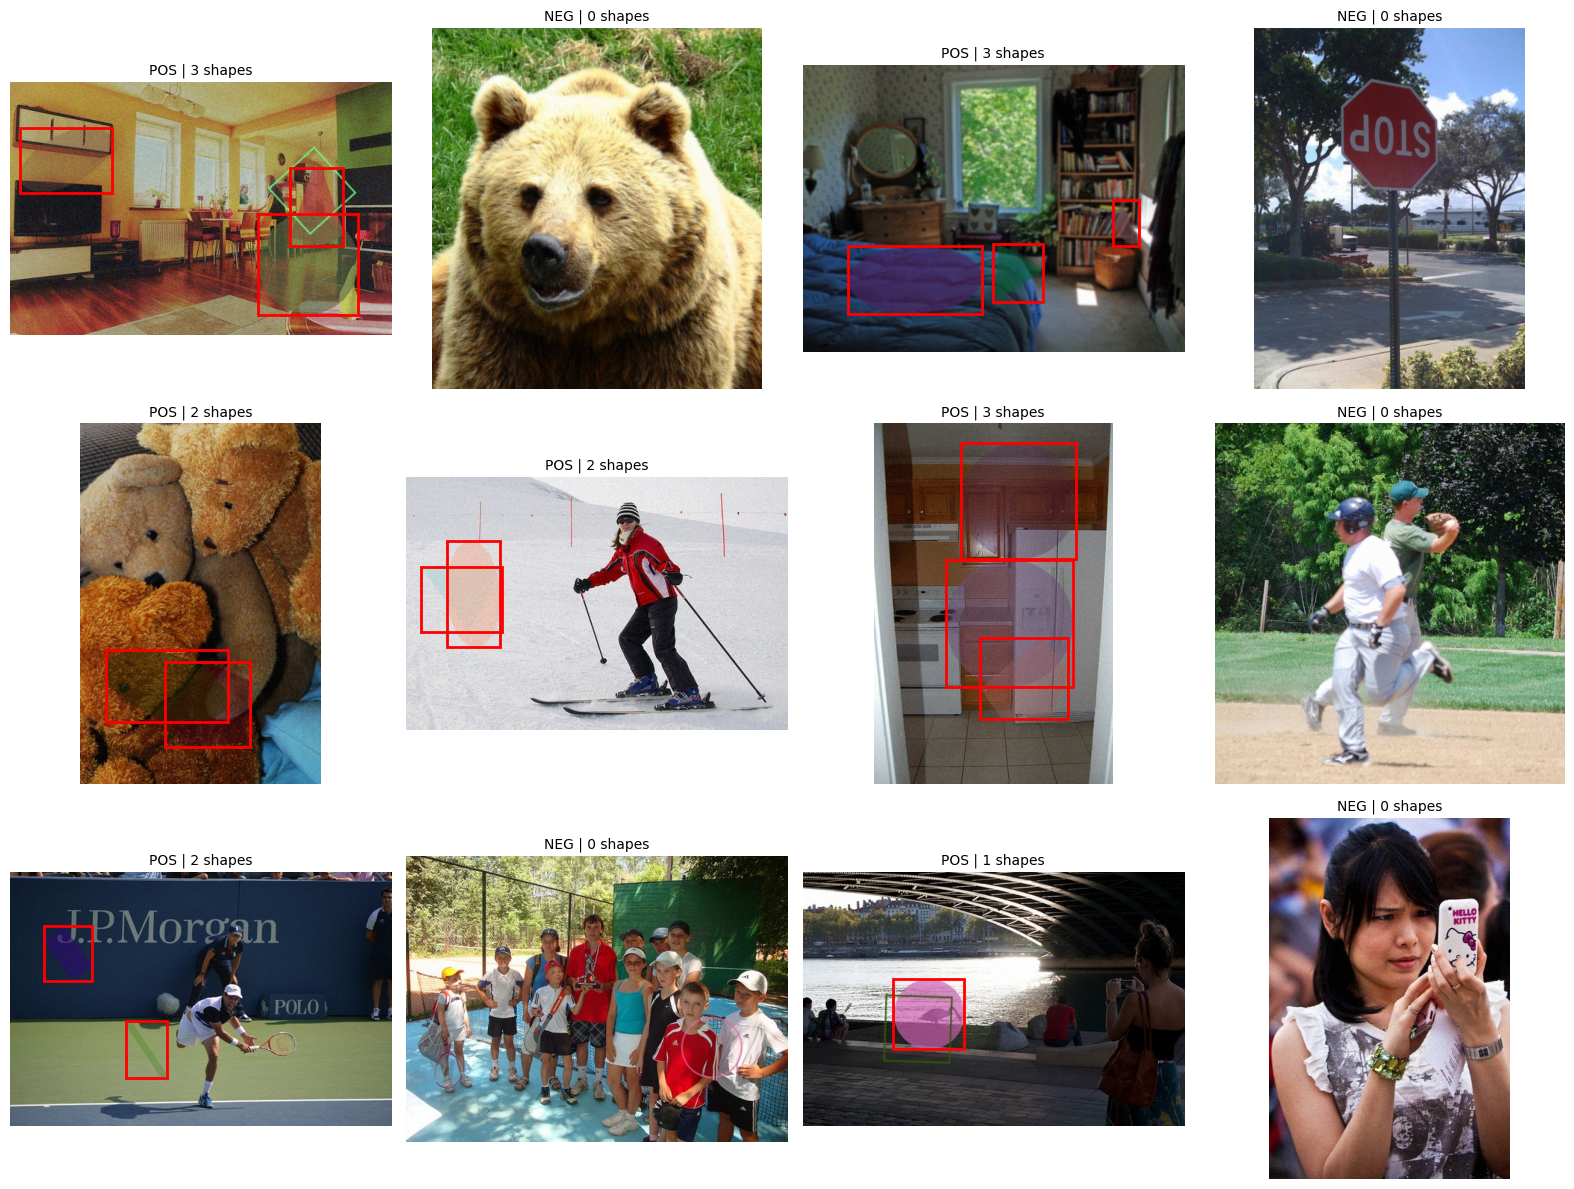

In [ ]:
# Cell 7 — Visualize 12 generated examples
import matplotlib.pyplot as plt, matplotlib.patches as patches
from PIL import Image
with open(os.path.join(OUT, "val_labels.json")) as f: val_labels = json.load(f)
files = sorted(val_labels.keys())[:12]
os.makedirs(os.path.join(OUT, "figures"), exist_ok=True)
plt.figure(figsize=(16, 12))
for i, fn in enumerate(files):
    rec = val_labels[fn]; img = Image.open(os.path.join(OUT, "val", fn)).convert("RGB")
    ax = plt.subplot(3, 4, i+1); ax.imshow(img); ax.axis("off")
    ax.set_title(f"{'POS' if rec['is_positive'] else 'NEG'} | {len(rec['boxes'])} shapes", fontsize=10)
    for x1, y1, x2, y2 in rec["boxes"]:
        ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor="red", linewidth=2))
plt.tight_layout(); plt.savefig(os.path.join(OUT, "figures", "generated_samples.png"), dpi=120, bbox_inches="tight"); plt.show()

In [ ]:
# Cell 8 — Zip for submission
shutil.make_archive("synthetic_data", "zip", OUT)
print("Created synthetic_data.zip (", round(os.path.getsize('synthetic_data.zip')/1e6, 1), "MB )")

Created synthetic_data.zip ( 705.7 MB )


In [ ]:
# Cell 9 — Upload to Drive
from google.colab import drive; drive.mount('/content/drive')
import shutil; shutil.copy('synthetic_data.zip', '/content/drive/MyDrive/synthetic_data.zip')

Mounted at /content/drive


'/content/drive/MyDrive/synthetic_data.zip'